In [2]:
#librerias necesarias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import holidays as hld

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler #Para estandarizar
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error
import sklearn.metrics as metrics

from sklearn.linear_model import Lasso, LassoCV

from sklearn.linear_model import ElasticNetCV

In [3]:
# carga del archivo
uber = pd.read_csv('uber_fares.csv')

## Analisis descriptivo

In [3]:
uber.info() #200000 registros

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


Convertimos los datos de fecha, a su dato correspondiente

In [4]:
uber['date'] = pd.to_datetime(uber['date'])
uber['pickup_datetime'] = pd.to_datetime(uber['pickup_datetime'])

In [521]:
uber.describe()

,key,date,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,2012-03-22 15:02:18.433115648,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
min,1.000000e+00,2009-01-01 01:15:22.000000600,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,2010-08-25 08:20:16,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,2012-03-21 20:44:29.500000256,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,2013-10-19 02:14:16.500000512,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,2015-06-30 23:40:39.000000100,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000
std,1.601382e+07,NaN,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997


### Creación de nuevas variables

In [5]:
def distancia(lat1, lon1, lat2, lon2):
    p = 0.017453292519943295
    a = 0.5 - np.cos((lat2 - lat1) * p)/2 + np.cos(lat1 * p) * np.cos(lat2 * p) * (1 - np.cos((lon2 - lon1) * p)) / 2
    return 0.6213712 * 12742 * np.arcsin(np.sqrt(a))

In [6]:
uber["distancia"] = distancia(uber["pickup_latitude"], uber["pickup_longitude"], uber["dropoff_latitude"], uber["dropoff_longitude"])

uber["hora"] = uber["pickup_datetime"].dt.hour
uber["fecha"] = uber["pickup_datetime"].dt.date
uber["día"] = uber["pickup_datetime"].dt.day_name()
uber["num_dia"] = uber["pickup_datetime"].dt.weekday

us_holidays = hld.US()
us_holidays = hld.country_holidays('US')

nyse_holidays = hld.NYSE()
nyse_holidays = hld.financial_holidays('NYSE')

uber["feriado"] = uber["fecha"].apply(lambda x: x in us_holidays or x in nyse_holidays)

### Valores atipicos

In [7]:
precios_negativos_cero = uber[uber["fare_amount"] <= 0]
print(f"Viajes con costos negativos: {precios_negativos_cero['passenger_count'].count()}")
# hay 17 valores negativos y 5 con valor 0

Viajes con costos negativos: 22


In [8]:
# Visualizo los valores de coordenadas que estan fuera de un rango razonable
'''
uber[((uber["pickup_longitude"] <= -180) | (uber["pickup_longitude"] >= 180)) |
    ((uber["dropoff_latitude"] <= -90) | (uber["dropoff_latitude"] >= 90)) |
    ((uber["pickup_latitude"] <= -90) | (uber["pickup_latitude"] >= 90)) |
    ((uber["dropoff_longitude"] <= -180) | (uber["dropoff_longitude"] >= 180))
    ]
  '''

'\nuber[((uber["pickup_longitude"] <= -180) | (uber["pickup_longitude"] >= 180)) |\n    ((uber["dropoff_latitude"] <= -90) | (uber["dropoff_latitude"] >= 90)) |\n    ((uber["pickup_latitude"] <= -90) | (uber["pickup_latitude"] >= 90)) |\n    ((uber["dropoff_longitude"] <= -180) | (uber["dropoff_longitude"] >= 180))\n    ]\n  '

In [8]:
# Reemplazar valores 0 por NaN (porque son inválidos)
columnas_coords = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']
uber[columnas_coords] = uber[columnas_coords].replace(0, np.nan)

# Reemplazar valores fuera de rango (latitudes: -90 a 90, longitudes: -180 a 180)
# Rango realista de coordenadas para NYC
lat_min, lat_max = 40.5, 41.0
lon_min, lon_max = -74.3, -73.5

#lat_min, lat_max = 39.5, 41.5
#lon_min, lon_max = -75.0, -73.0

for col in columnas_coords:
    if 'latitude' in col:
        uber.loc[(uber[col] < lat_min) | (uber[col] > lat_max), col] = np.nan
    elif 'longitude' in col:
        uber.loc[(uber[col] < lon_min) | (uber[col] > lon_max), col] = np.nan

# Reemplazar distancia inválida por NaN y distancias muy bajas
uber['distancia'] = uber['distancia'].apply(lambda x: np.nan if x <= 0.1 else x)

# Eliminar outliers de distancia (basado en IQR)
q1 = uber["distancia"].quantile(0.25)
q3 = uber["distancia"].quantile(0.75)
iqr = q3 - q1
limite_inferior = max(q1 - 1.5 * iqr, 0)
limite_superior = q3 + 1.5 * iqr

uber['distancia'] = uber['distancia'].apply(lambda x: np.nan if x < limite_inferior or x > limite_superior else x)

# (OPCIONAL) Si querés, podés dejar esta línea comentada si vas a imputar distancia de otro modo
#uber.loc[uber['distancia'].isna(), columnas_coords] = np.nan

# Reemplazar valor imposible en cantidad de pasajeros
uber.loc[uber['passenger_count'] == 208, 'passenger_count'] = np.nan

# Eliminar tarifas <= 0
uber = uber[uber["fare_amount"] > 0]

# Eliminar outliers de tarifa
uber.drop(uber[uber["fare_amount"] > 300].index, inplace=True)

# MOSTRAR VALORES FALTANTES
print(uber.isna().sum())

key                      0
date                     0
fare_amount              0
pickup_datetime          0
pickup_longitude      4056
pickup_latitude       4044
dropoff_longitude     4025
dropoff_latitude      4038
passenger_count          1
distancia            23436
hora                     0
fecha                    0
día                      0
num_dia                  0
feriado                  0
dtype: int64


In [10]:
# Chequeamos el % de datos eliminados

porcentaje_eliminados = round((200000- len(uber)) / 200000 * 100, 2)
print(f"Se eliminaron el {porcentaje_eliminados}% de los datos")

Se eliminaron el 0.01% de los datos


In [9]:
# Diagnóstico: coordenadas aún inválidas (NaN o 0)

columnas_coords = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']

# Condición: al menos una coordenada es NaN o igual a 0
condicion_nan = uber[columnas_coords].isna().any(axis=1)
condicion_cero = (uber[columnas_coords] == 0).any(axis=1)

# Filas que cumplen alguna de las dos condiciones
filas_con_problemas = uber[condicion_nan | condicion_cero]

# Mostrar las filas con problemas en las coordenadas
print(filas_con_problemas[columnas_coords])

        pickup_latitude  pickup_longitude  dropoff_latitude  dropoff_longitude
7                   NaN               NaN               NaN                NaN
11                  NaN               NaN               NaN                NaN
65                  NaN               NaN               NaN                NaN
92                  NaN               NaN               NaN                NaN
120                 NaN               NaN               NaN                NaN
...                 ...               ...               ...                ...
199724              NaN               NaN               NaN                NaN
199880              NaN               NaN               NaN                NaN
199883              NaN               NaN               NaN                NaN
199936        40.774307               NaN         40.769672         -73.982215
199963              NaN               NaN               NaN                NaN

[4349 rows x 4 columns]


In [529]:
#uber["distancia"] = distancia(uber["pickup_latitude"], uber["pickup_longitude"], uber["dropoff_latitude"], uber["dropoff_longitude"])

In [12]:
uber[uber["distancia"].isna()]

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distancia,hora,fecha,día,num_dia,feriado
5,44470845,2011-02-12 02:27:09.000000600,4.90,2011-02-12 02:27:09+00:00,-73.969019,40.755910,-73.969019,40.755910,1.0,NaN,2,2011-02-12,Saturday,5,False
6,48725865,2014-10-12 07:04:00.000000200,24.50,2014-10-12 07:04:00+00:00,-73.961447,40.693965,-73.871195,40.774297,5.0,NaN,7,2014-10-12,Sunday,6,False
7,44195482,2012-12-11 13:52:00.000000290,2.50,2012-12-11 13:52:00+00:00,NaN,NaN,NaN,NaN,1.0,NaN,13,2012-12-11,Tuesday,1,False
11,6379048,2011-05-23 22:15:00.000000860,8.50,2011-05-23 22:15:00+00:00,NaN,NaN,NaN,NaN,1.0,NaN,22,2011-05-23,Monday,0,False
30,31945670,2011-05-21 09:00:00.000000310,25.70,2011-05-21 09:00:00+00:00,-73.944815,40.834367,-73.989332,40.721920,4.0,NaN,9,2011-05-21,Saturday,5,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199976,1780041,2011-10-18 23:53:00.000000145,49.70,2011-10-18 23:53:00+00:00,-73.978225,40.783318,-73.700963,40.705852,1.0,NaN,23,2011-10-18,Tuesday,1,False
199977,21117828,2012-11-20 21:04:30.000000100,43.50,2012-11-20 21:04:30+00:00,-73.996671,40.737483,-73.867758,40.897563,1.0,NaN,21,2012-11-20,Tuesday,1,False
199982,13096190,2014-08-06 11:06:06.000000100,57.33,2014-08-06 11:06:06+00:00,-73.969204,40.754771,-73.790351,40.643802,1.0,NaN,11,2014-08-06,Wednesday,2,False
199995,42598914,2012-10-28 10:49:00.000000530,3.00,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1.0,NaN,10,2012-10-28,Sunday,6,False


### Valores Nulos

In [13]:
uber.isna().sum()

key                      0
date                     0
fare_amount              0
pickup_datetime          0
pickup_longitude      4056
pickup_latitude       4044
dropoff_longitude     4025
dropoff_latitude      4038
passenger_count          1
distancia            23436
hora                     0
fecha                    0
día                      0
num_dia                  0
feriado                  0
dtype: int64

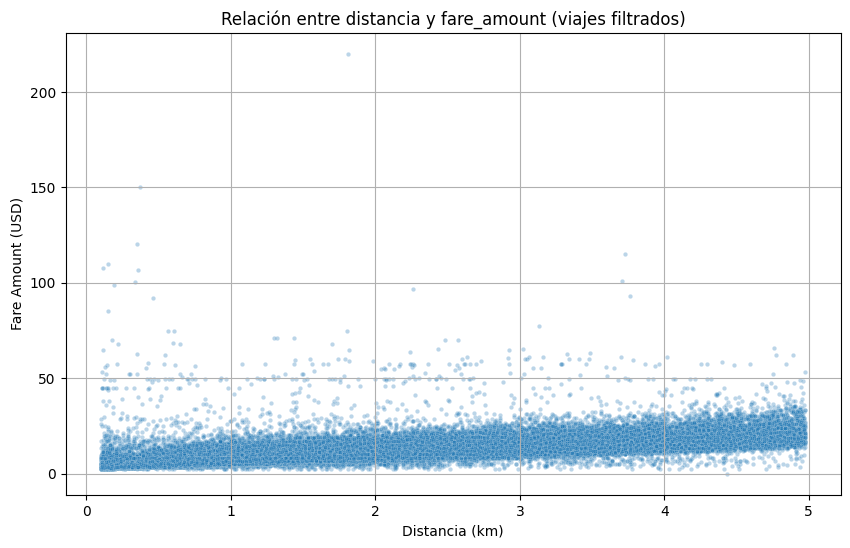

'\nsns.lmplot(data=uber, x="distancia", y="fare_amount", scatter_kws={"alpha":0.2, "s":10}, line_kws={"color":"red"})\nplt.title("Tendencia lineal entre distancia y fare_amount")\nplt.xlabel("Distancia (km)")\nplt.ylabel("Fare Amount (USD)")\nplt.grid(True)\nplt.show()\n'

In [10]:
# Grafico fare amount ANTES de la imputación

plt.figure(figsize=(10, 6))
sns.scatterplot(data=uber, x="distancia", y="fare_amount", alpha=0.3, s=10)
plt.title("Relación entre distancia y fare_amount (viajes filtrados)")
plt.xlabel("Distancia (km)")
plt.ylabel("Fare Amount (USD)")
plt.grid(True)
plt.show()
'''
sns.lmplot(data=uber, x="distancia", y="fare_amount", scatter_kws={"alpha":0.2, "s":10}, line_kws={"color":"red"})
plt.title("Tendencia lineal entre distancia y fare_amount")
plt.xlabel("Distancia (km)")
plt.ylabel("Fare Amount (USD)")
plt.grid(True)
plt.show()
'''

In [11]:
# Opcion 1: Imputación simple por la mediana de las coordenadas

from sklearn.impute import SimpleImputer

columnas_a_imputar = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']

imputer = SimpleImputer(strategy='median')  # o 'mean'
uber[columnas_a_imputar] = imputer.fit_transform(uber[columnas_a_imputar])

In [184]:
# Opcion 2: Imputación knn de las coordenadas

from sklearn.impute import KNNImputer
import numpy as np

# 1. Seleccionamos las columnas de coordenadas
columnas_a_imputar = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']

# 2. Imputamos coordenadas con KNN
imputer = KNNImputer(n_neighbors=5)
coordenadas_imputadas = imputer.fit_transform(uber[columnas_a_imputar])

# 3. Agregamos ruido gaussiano pequeño
#ruido = np.random.normal(loc=0, scale=0.0005, size=coordenadas_imputadas.shape)
#coordenadas_imputadas_con_ruido = coordenadas_imputadas + ruido

# 4. Asignamos de vuelta al dataframe
uber[columnas_coords] = coordenadas_imputadas


<ipython-input-184-f73d56517f7d>:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  uber[uber["passenger_count"].isna()] = uber["passenger_count"].median()
<ipython-input-184-f73d56517f7d>:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with datetime64[ns, UTC], please explicitly cast to a compatible dtype first.
  uber[uber["passenger_count"].isna()] = uber["passenger_count"].median()
<ipython-input-184-f73d56517f7d>:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  uber[uber["passenger_count"].isna()] = uber["passenger

In [12]:
# Imputo el único valor NaN de passenger_count

uber[uber["passenger_count"].isna()] = uber["passenger_count"].median()

C:\Users\marya\AppData\Local\Temp\ipykernel_8696\1800890423.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  uber[uber["passenger_count"].isna()] = uber["passenger_count"].median()
C:\Users\marya\AppData\Local\Temp\ipykernel_8696\1800890423.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with datetime64[ns, UTC], please explicitly cast to a compatible dtype first.
  uber[uber["passenger_count"].isna()] = uber["passenger_count"].median()
C:\Users\marya\AppData\Local\Temp\ipykernel_8696\1800890423.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.0' has dtype incompatible with bool, please explicitly cas

In [13]:
# Imputación simple por la mediana de la distancia

from sklearn.impute import SimpleImputer

columnas_a_imputar = ['distancia']

imputer = SimpleImputer(strategy='median')  # o 'mean'
uber[columnas_a_imputar] = imputer.fit_transform(uber[columnas_a_imputar])

In [14]:
# Recalculo la distancia despúes de haber imputado

uber["distancia"] = distancia(
    uber["pickup_latitude"],
    uber["pickup_longitude"],
    uber["dropoff_latitude"],
    uber["dropoff_longitude"]
)

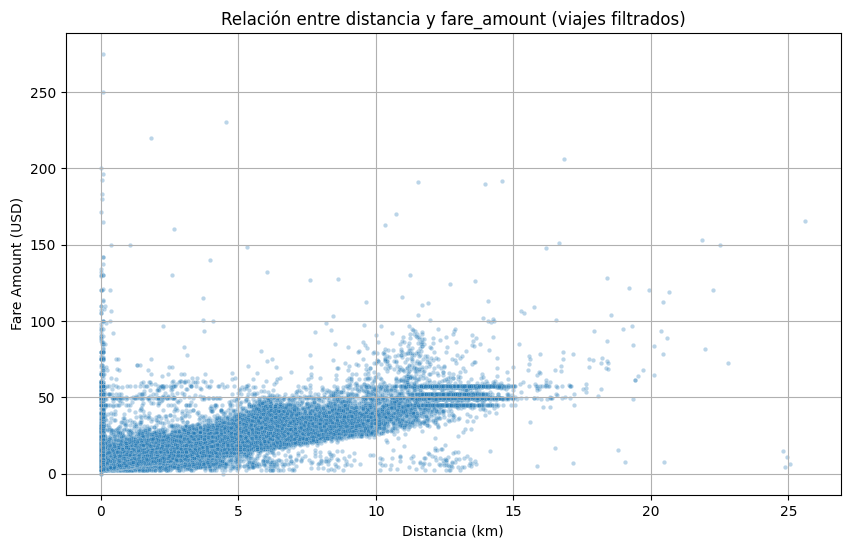

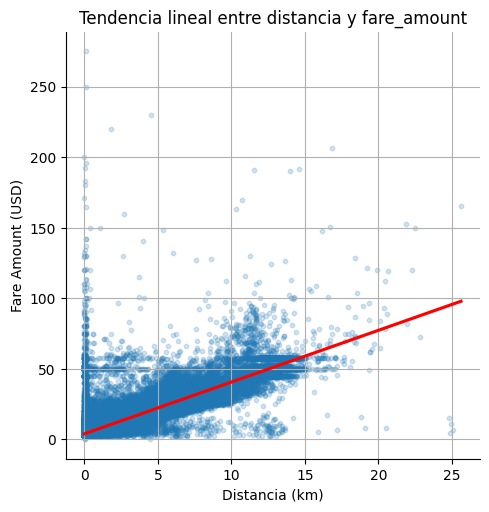

In [15]:
# Grafico fare amount DESPUÉS de la imputación

plt.figure(figsize=(10, 6))
sns.scatterplot(data=uber, x="distancia", y="fare_amount", alpha=0.3, s=10)
plt.title("Relación entre distancia y fare_amount (viajes filtrados)")
plt.xlabel("Distancia (km)")
plt.ylabel("Fare Amount (USD)")
plt.grid(True)
plt.show()

sns.lmplot(data=uber, x="distancia", y="fare_amount", scatter_kws={"alpha":0.2, "s":10}, line_kws={"color":"red"})
plt.title("Tendencia lineal entre distancia y fare_amount")
plt.xlabel("Distancia (km)")
plt.ylabel("Fare Amount (USD)")
plt.grid(True)
plt.show()


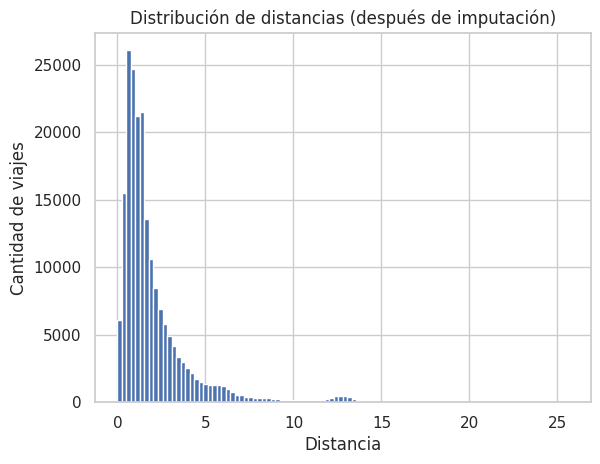

In [538]:
# Distribución de las distancias después de la imputación

plt.hist(uber['distancia'], bins=100)
plt.title("Distribución de distancias (después de imputación)")
plt.xlabel("Distancia")
plt.ylabel("Cantidad de viajes")
plt.show()

### Graficos

Text(0.5, 1.0, 'Ubicaciones de recogida y destino')

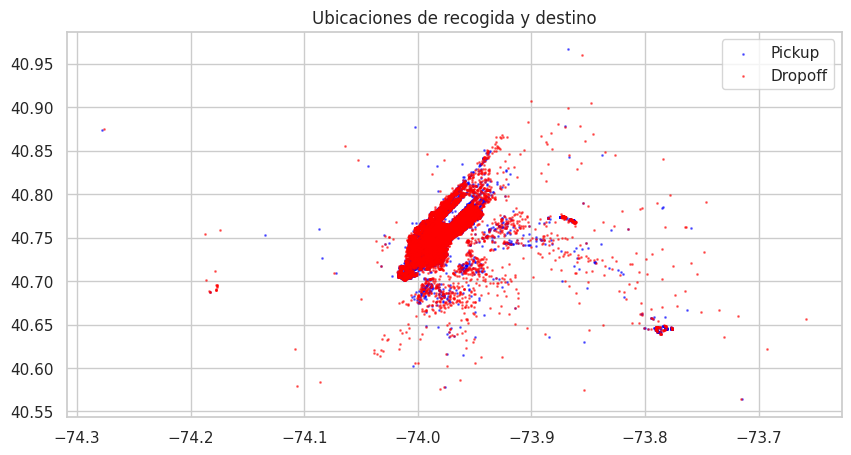

In [344]:
# Muestra una parte del dataset para evitar sobrecarga visual
sample = uber.sample(10000)
plt.figure(figsize=(10,5))
plt.scatter(sample['pickup_longitude'], sample['pickup_latitude'], c='blue', s=1, label='Pickup', alpha=0.5)
plt.scatter(sample['dropoff_longitude'], sample['dropoff_latitude'], c='red', s=1, label='Dropoff', alpha=0.5)
plt.legend()
plt.title("Ubicaciones de recogida y destino")

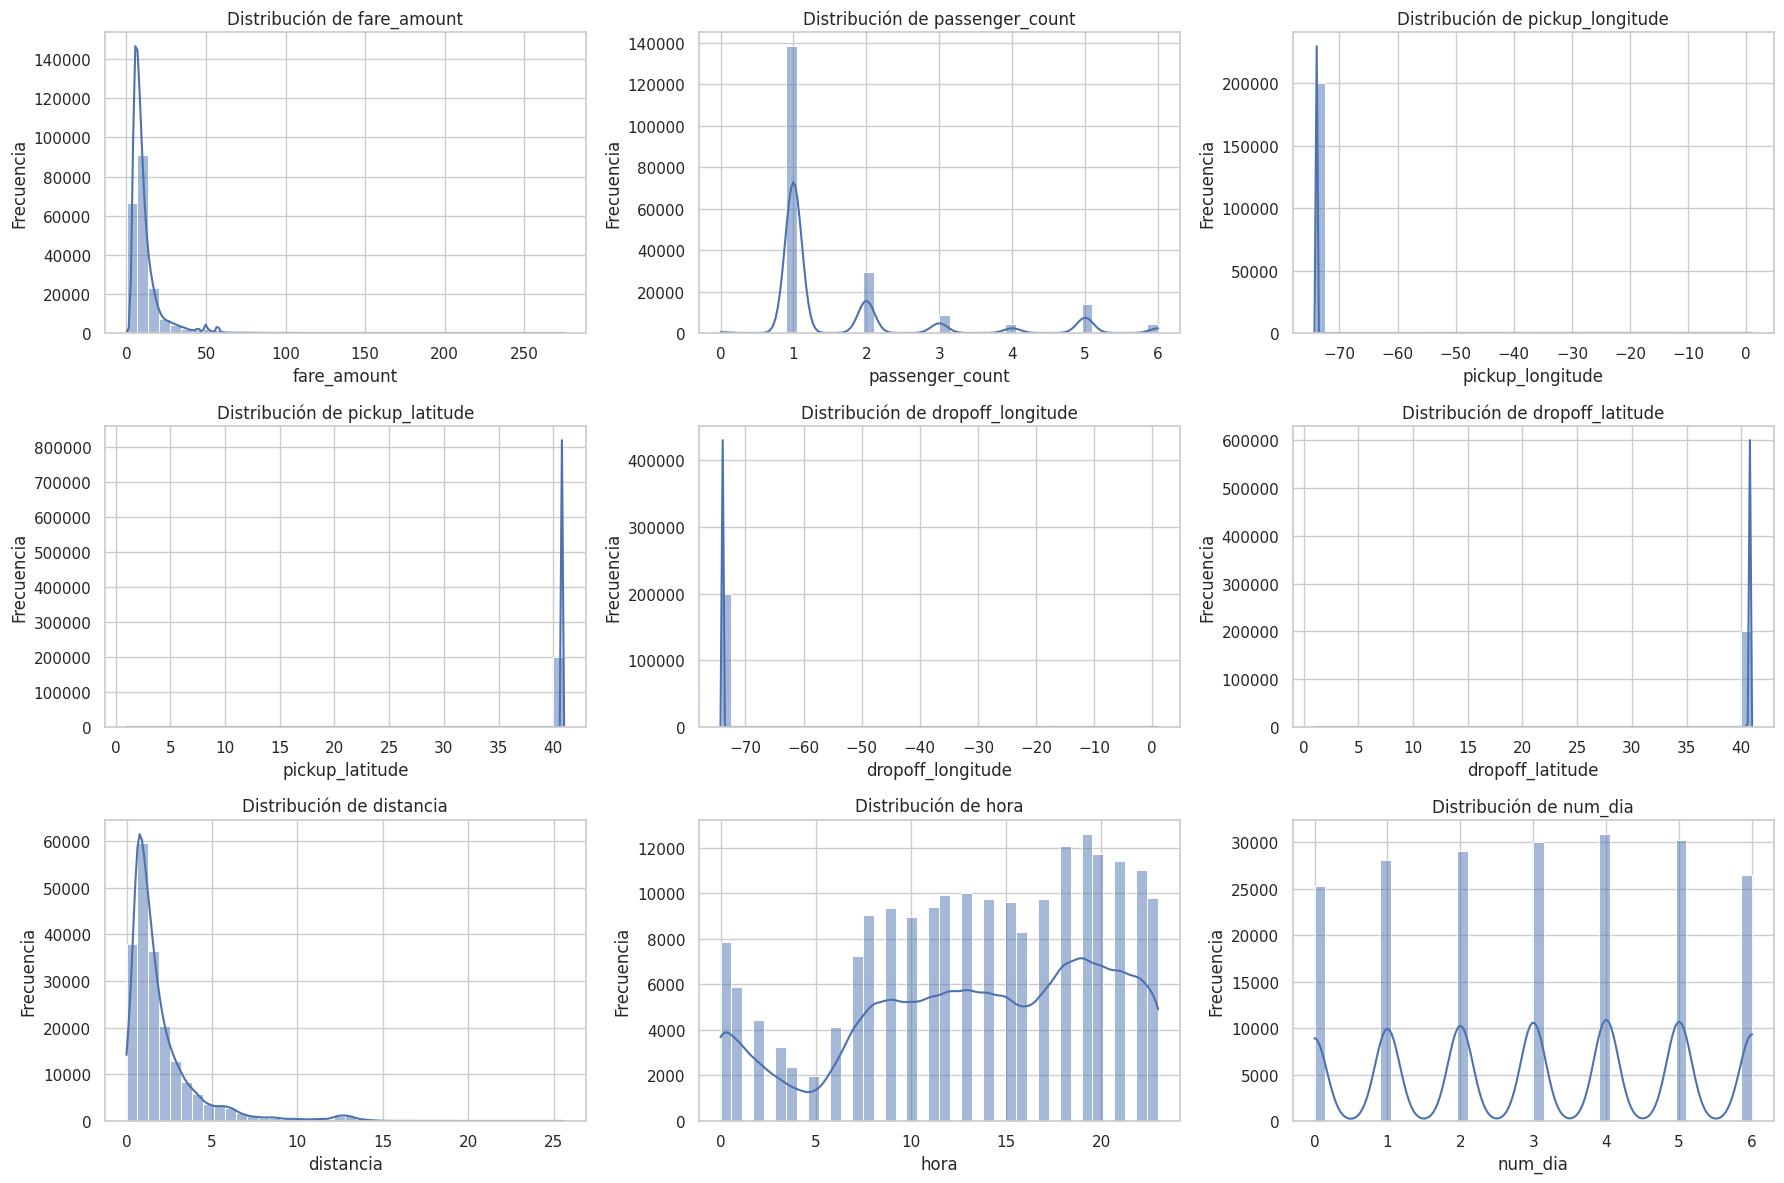

In [345]:
# Variables numéricas relevantes
variables = ["fare_amount", "passenger_count", "pickup_longitude", "pickup_latitude",
             "dropoff_longitude", "dropoff_latitude", "distancia", "hora", "num_dia"]

# Estilo
sns.set(style="whitegrid")

# Creamos los subplots
fig, axs = plt.subplots(3, 3, figsize=(18, 12))
axs = axs.flatten()

# Generamos un histograma por cada variable
for i, col in enumerate(variables):
    sns.histplot(data=uber, x=col, bins=40, ax=axs[i], kde=True)
    axs[i].set_title(f"Distribución de {col}")
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

heatmap hora vs día para ver en qué momento del día hay más viajes según el día de la semana

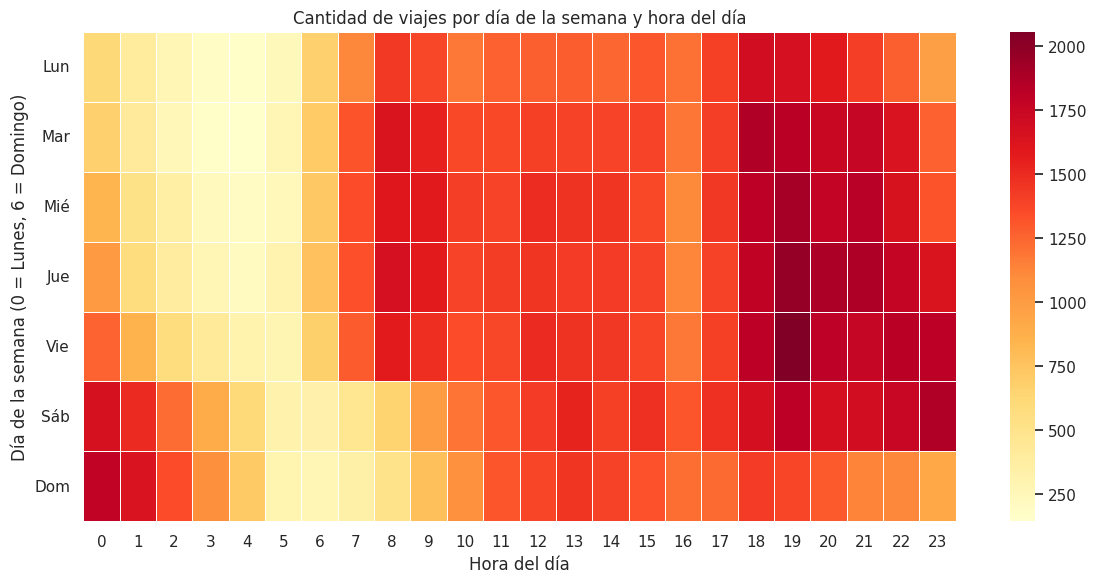

In [346]:
# Creamos una tabla resumen con la cantidad de viajes por día y hora
heatmap_data = uber.groupby(["num_dia", "hora"]).size().unstack(fill_value=0)

# Creamos el heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=False, linewidths=0.5)

# Títulos y etiquetas
plt.title("Cantidad de viajes por día de la semana y hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana (0 = Lunes, 6 = Domingo)")
plt.yticks(ticks=[i + 0.5 for i in range(7)], labels=["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"], rotation=0)

plt.tight_layout()
plt.show()

fare_amount

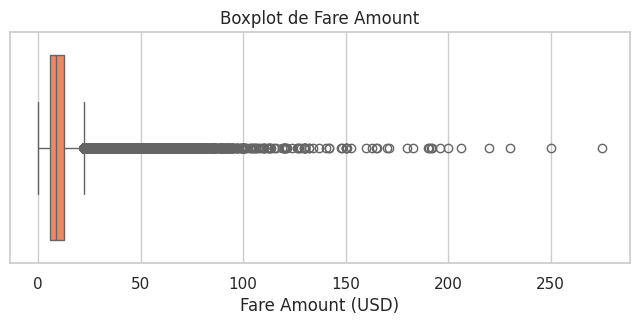

In [347]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=uber["fare_amount"], color="coral")
plt.title("Boxplot de Fare Amount")
plt.xlabel("Fare Amount (USD)")
plt.show()


passenger_count vs fare_amount (¿hay correlación entre los pasajeros y el precio?)

<ipython-input-348-b73ae6cab775>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=uber, x="passenger_count", y="fare_amount", palette="Set2")


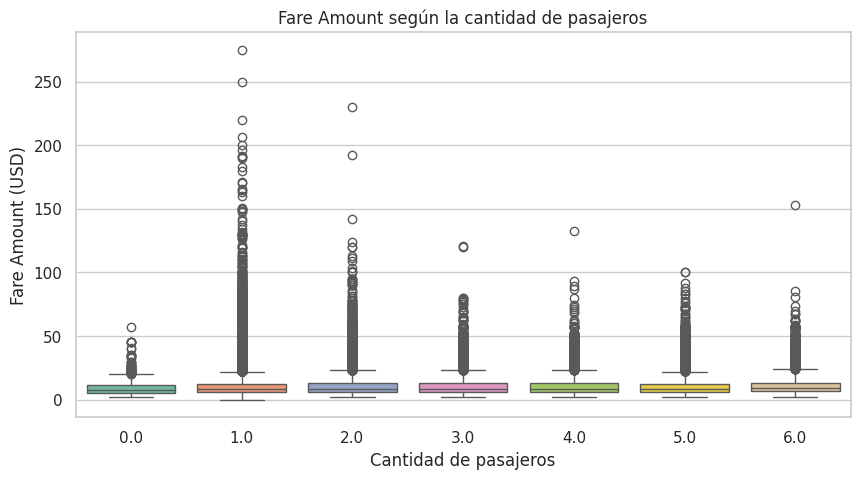

In [348]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=uber, x="passenger_count", y="fare_amount", palette="Set2")
plt.title("Fare Amount según la cantidad de pasajeros")
plt.xlabel("Cantidad de pasajeros")
plt.ylabel("Fare Amount (USD)")
plt.show()

fare_amount vs distancia

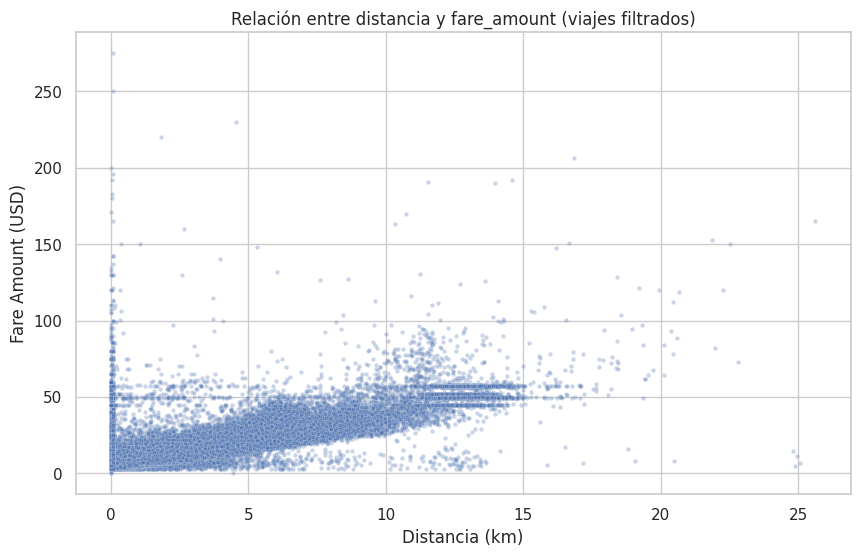

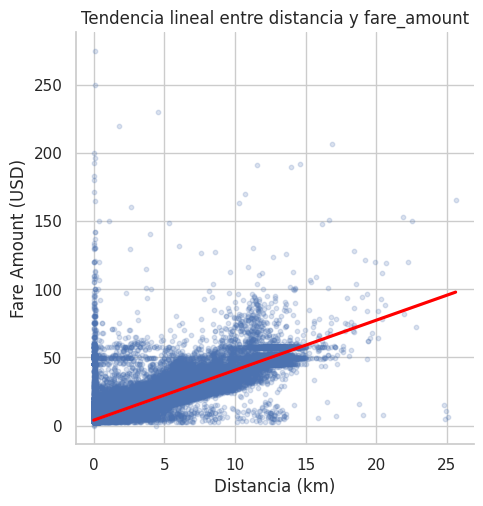

In [349]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=uber, x="distancia", y="fare_amount", alpha=0.3, s=10)
plt.title("Relación entre distancia y fare_amount (viajes filtrados)")
plt.xlabel("Distancia (km)")
plt.ylabel("Fare Amount (USD)")
plt.grid(True)
plt.show()

sns.lmplot(data=uber, x="distancia", y="fare_amount", scatter_kws={"alpha":0.2, "s":10}, line_kws={"color":"red"})
plt.title("Tendencia lineal entre distancia y fare_amount")
plt.xlabel("Distancia (km)")
plt.ylabel("Fare Amount (USD)")
plt.grid(True)
plt.show()


In [19]:
columnas_sin_corr = ["fare_amount", "passenger_count", "distancia", "día", "feriado","key","fecha","pickup_datetime"]
matriz = uber.drop(columns=columnas_sin_corr)
corr = matriz.corr()
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 6}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.title("Matriz de correlación")
plt.show()

TypeError: float() argument must be a string or a real number, not 'Timestamp'

### Estandarización y division del dataset

In [16]:
'''
columnas_cualitativas = ["passenger_count","distancia"]
scaler = StandardScaler().set_output(transform="pandas")
X_estandarizado = scaler.fit_transform(uber[columnas_cualitativas])
X_estandarizado["feriado"] = uber["feriado"]
X_estandarizado["dia"] = uber["num_dia"]
X_estandarizado["hora"] = uber["hora"]
y = uber["fare_amount"]
'''

columnas_numericas = ["passenger_count","distancia"]
scaler = StandardScaler().set_output(transform="pandas")

# Escalar y resetear índice
X_scaled = scaler.fit_transform(uber[columnas_numericas]).reset_index(drop=True)

# Concatenar con otras columnas (también con índice reseteado)
otras_columnas = uber[["feriado", "num_dia", "hora"]].reset_index(drop=True)

# Combinar todo
X_estandarizado = pd.concat([X_scaled, otras_columnas], axis=1)

# Target
y = uber["fare_amount"].reset_index(drop=True)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_estandarizado, y, test_size=0.2, random_state=42)

## Modelos de regresión

### Regresión lineal
$$
\text{fare\_amount} = 11.69 + 0.099 \cdot \text{passenger\_count} + 0.542 \cdot \text{distancia} - 0.0077 \cdot \text{feriado} + 0.0247 \cdot \text{dia} - 0.0311 \cdot \text{hora}
$$

In [18]:
X_train.columns

Index(['passenger_count', 'distancia', 'feriado', 'num_dia', 'hora'], dtype='object')

In [19]:
modelo = LinearRegression().fit(X_train,y_train)

In [20]:
modelo.coef_

array([ 3.76925074e-02,  8.18298110e+00, -5.24321535e-01, -3.68784526e-02,
        6.31960253e-03])

In [21]:
modelo.intercept_

np.float64(11.39995550610112)

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predicciones
y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

# Métricas
def print_metrics(y_true, y_pred, dataset=""):
    print(f"--- {dataset} ---")
    print("R2 Score:", r2_score(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE:", mean_absolute_error(y_true, y_pred))

print_metrics(y_train, y_pred_train, "Entrenamiento")
print_metrics(y_test, y_pred_test, "Prueba")


#  R2 Score: Qué proporción de la varianza del target explica el modelo (idealmente cerca de 1).

#  MSE / RMSE: Error cuadrático medio y su raíz, útiles para penalizar errores grandes.

#  MAE: Error absoluto medio (más robusto ante outliers).

--- Entrenamiento ---
R2 Score: 0.6909843963507297
MSE: 30.09004239828212
RMSE: 5.485439125382955
MAE: 2.6030025939949866
--- Prueba ---
R2 Score: 0.6956972584872306
MSE: 27.82878553595284
RMSE: 5.275299568361293
MAE: 2.5774229823440233


### Gradiente descendiente

In [23]:
from sklearn.linear_model import SGDRegressor
import matplotlib.pyplot as plt

sgd = SGDRegressor(loss='squared_error', penalty=None, learning_rate='invscaling', eta0=0.01, max_iter=1000, random_state=42)
sgd.fit(X_train, y_train)

y_pred_sgd_train = sgd.predict(X_train)
y_pred_sgd_test = sgd.predict(X_test)

print_metrics(y_train, y_pred_sgd_train, "Entrenamiento (SGD)")
print_metrics(y_test, y_pred_sgd_test, "Prueba (SGD)")


--- Entrenamiento (SGD) ---
R2 Score: 0.675041570707291
MSE: 31.64245688445794
RMSE: 5.625162831817221
MAE: 2.57602168361215
--- Prueba (SGD) ---
R2 Score: 0.6786021114931797
MSE: 29.392153572132916
RMSE: 5.421453086777835
MAE: 2.560642201787912


### Ridge Regression

In [24]:
# === CREACIÓN Y ENTRENAMIENTO DEL MODELO RIDGE CON CROSS-VALIDATION ===
modelo = RidgeCV(
    alphas=np.logspace(-10, 2, 200),
    fit_intercept=True,
    store_cv_values=True
)

_ = modelo.fit(X=X_train, y=y_train)

C:\Users\marya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


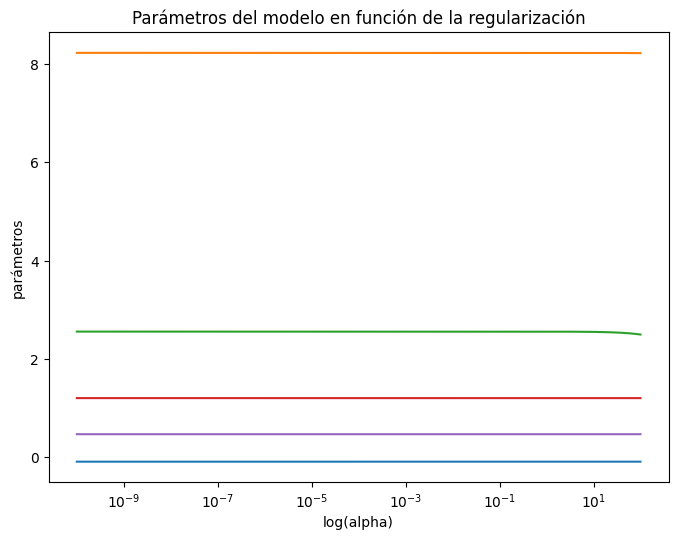

In [25]:
# === EVOLUCIÓN DE LOS PARÁMETROS EN FUNCIÓN DE ALPHA ===
alphas = modelo.alphas
coefs = []

for alpha in alphas:
    modelo_temp = Ridge(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(8, 5.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlabel('log(alpha)')
ax.set_ylabel('parámetros')
ax.set_title('Parámetros del modelo en función de la regularización')
plt.axis('tight')
plt.show()

In [26]:
# === EVOLUCIÓN DEL ERROR DE VALIDACIÓN CRUZADA EN FUNCIÓN DE ALPHA ===
mse_cv = modelo.cv_values_.reshape((-1, 200)).mean(axis=0)
mse_sd = modelo.cv_values_.reshape((-1, 200)).std(axis=0)

# De MSE a RMSE
rmse_cv = np.sqrt(mse_cv)
rmse_sd = np.sqrt(mse_sd)

# Mejor alpha encontrado
min_rmse = np.min(rmse_cv)
optimo = modelo.alphas[np.argmin(rmse_cv)]

C:\Users\marya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:110: FutureWarning: Attribute `cv_values_` is deprecated in version 1.5 and will be removed in 1.7. Use `cv_results_` instead.
  warnings.warn(msg, category=FutureWarning)


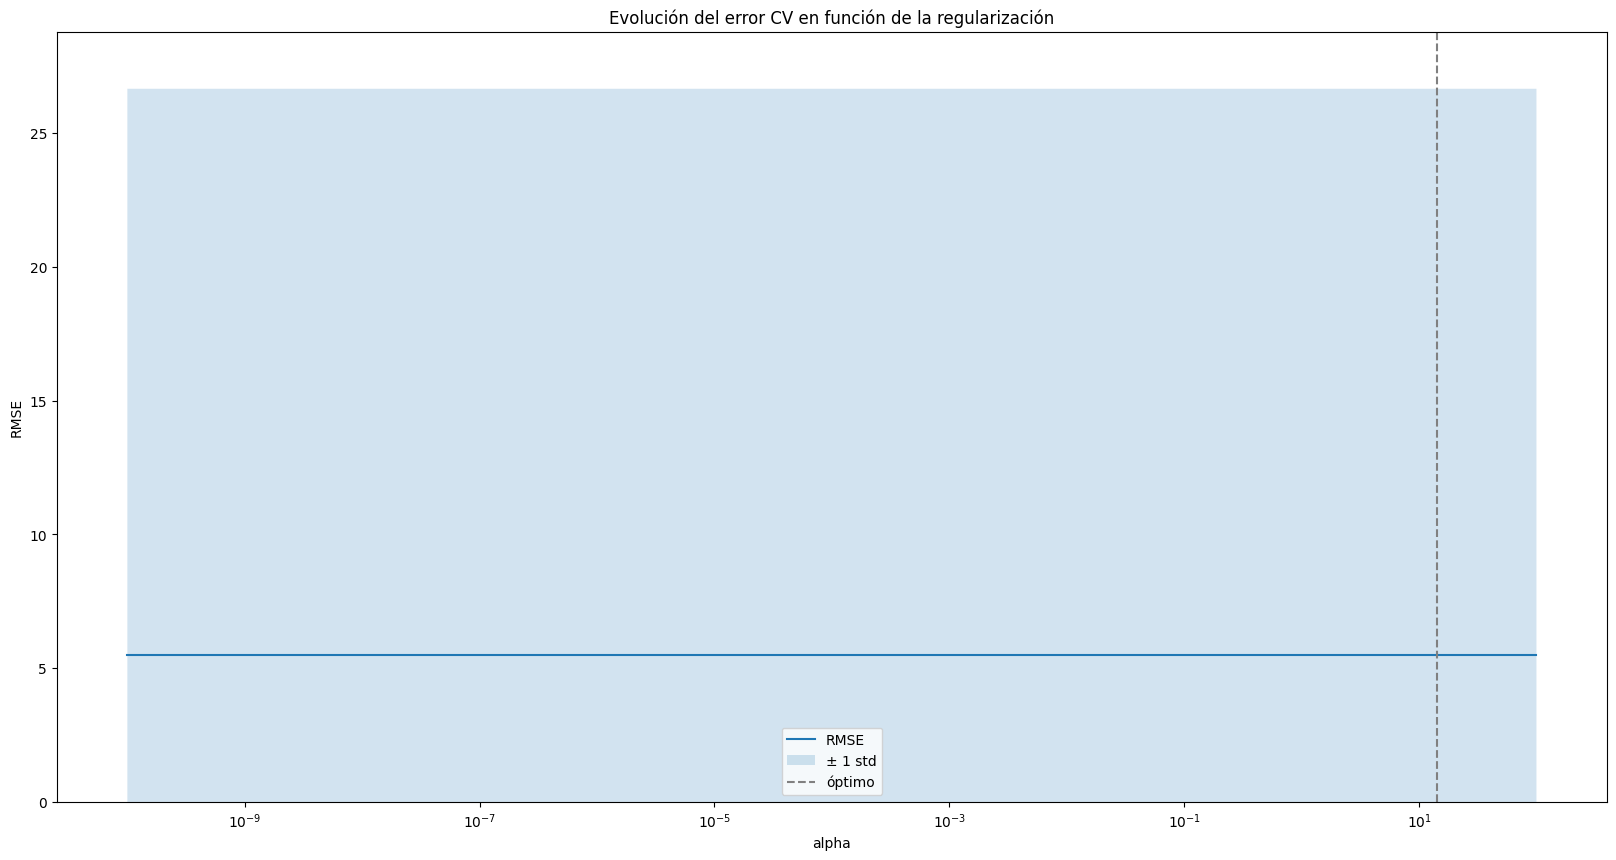

Mejor valor de alpha encontrado: 14.314589375234757


In [27]:
# === GRÁFICO DEL ERROR +- 1 DESVIACIÓN ESTÁNDAR ===
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(modelo.alphas, rmse_cv, label='RMSE')
ax.fill_between(
    modelo.alphas,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha=0.2,
    label='± 1 std'
)

ax.axvline(x=optimo, c="gray", linestyle='--', label='óptimo')

ax.set_xscale('log')
ax.set_ylim([0, None])
ax.set_title('Evolución del error CV en función de la regularización')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
plt.legend()
plt.show()

print(f"Mejor valor de alpha encontrado: {modelo.alpha_}")

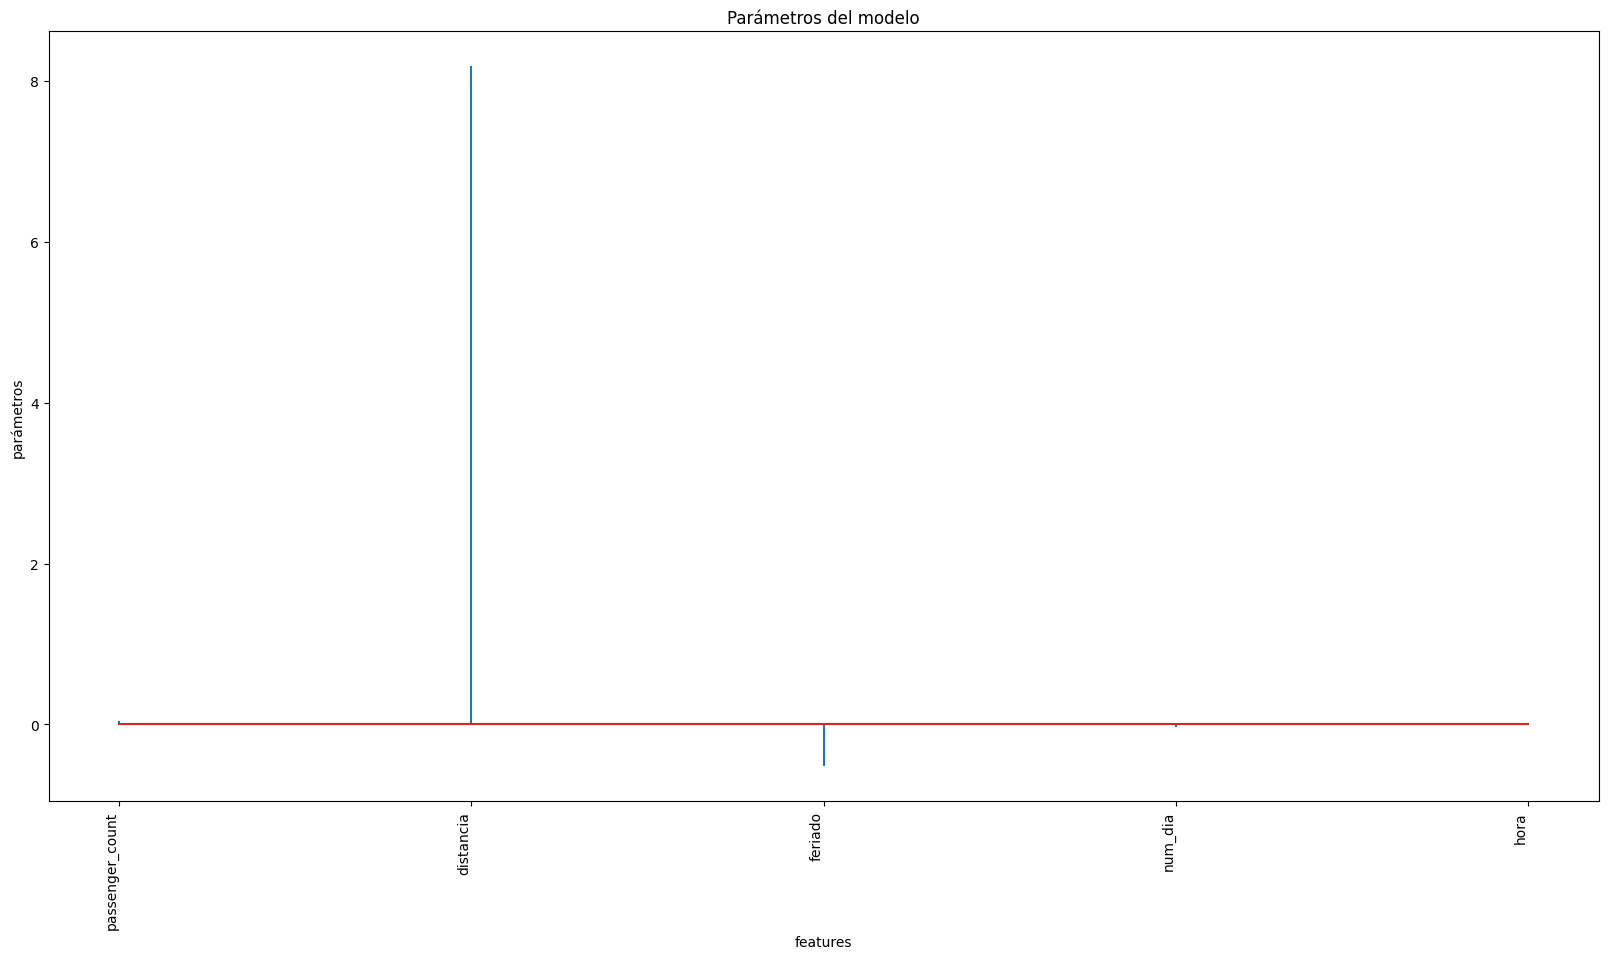

In [28]:
# === PARÁMETROS DEL MODELO ===
df_coeficientes = pd.DataFrame(
    {'predictor': X_train.columns,  # asegurate que X_train sea un DataFrame y no un array
     'coef': modelo.coef_.flatten()}
)

fig, ax = plt.subplots(figsize=(20, 10))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('features')
ax.set_ylabel('parámetros')
ax.set_title('Parámetros del modelo')
plt.show()

In [29]:
# === PREDICCIONES EN TEST ===
predicciones = modelo.predict(X_test).flatten()
predicciones[:10]

array([ 6.97273893, 10.73888792, 11.46382269, 13.05620597, 11.07560634,
       17.22199051,  7.25400743, 21.64655038,  8.10725173, 12.42237638])

In [30]:
# === ERROR DEL MODELO EN TEST ===
rmse_ridge = mean_squared_error(
    y_true=y_test,
    y_pred=predicciones,
    
)
print(f"El error (rmse) de test es: {rmse_ridge}")

El error (rmse) de test es: 27.82863471510423


In [31]:
# R² Score
R2 = metrics.r2_score(y_test, predicciones)
print(f"R² en test: {R2}")

R² en test: 0.6956989076859588


### Variación hiperparámetros de Ridge

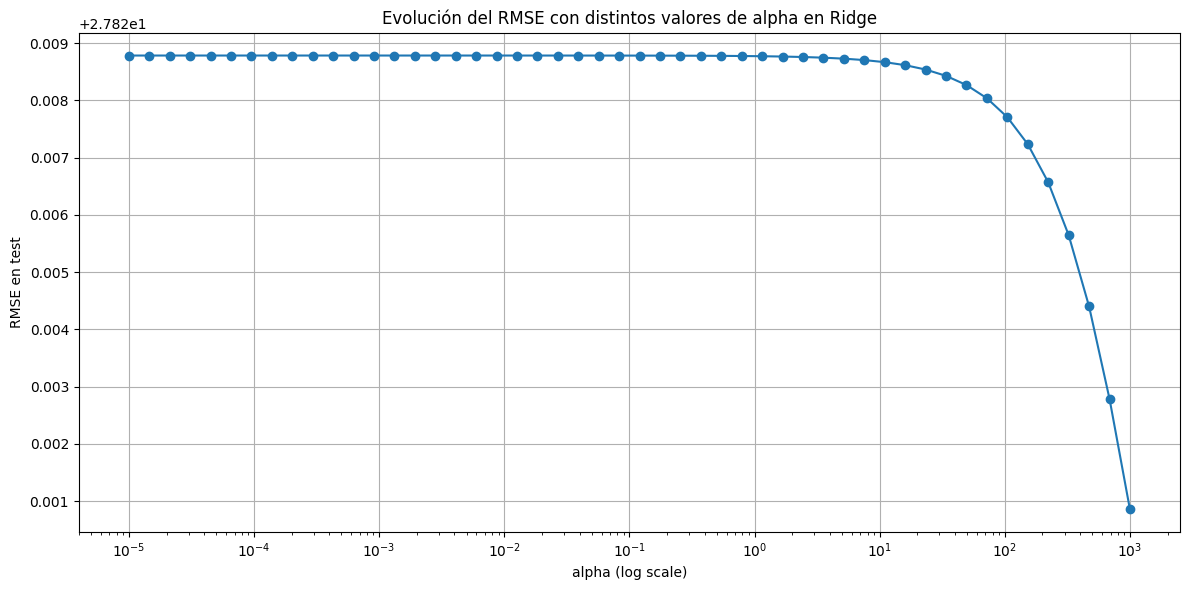

In [52]:
# Valores de alpha a testear (desde muy baja hasta alta regularización)
valores_alpha = np.logspace(-5, 3, 50)  # de 10^-5 a 10^3

# Lista para guardar los RMSEs
rmse_alphas = []

# Entrenamiento y evaluación por cada alpha
for alpha in valores_alpha:
    modelo_ridge = Ridge(alpha=alpha)
    modelo_ridge.fit(X_train, y_train)
    predicciones = modelo_ridge.predict(X_test)
    rmse = mean_squared_error(y_test, predicciones)
    rmse_alphas.append(rmse)

# Convertir a DataFrame para análisis o visualización
df_ridge_alphas = pd.DataFrame({
    'alpha': valores_alpha,
    'rmse': rmse_alphas
})

# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(df_ridge_alphas['alpha'], df_ridge_alphas['rmse'], marker='o')
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('RMSE en test')
plt.title('Evolución del RMSE con distintos valores de alpha en Ridge')
plt.grid(True)
plt.tight_layout()
plt.show()

### Lasso Regression

In [32]:
# === MODELO LASSO CON CROSS-VALIDATION ===
modelo = LassoCV(
    alphas=np.logspace(-10, 3, 200),
    cv=10
)

_ =  modelo.fit(X=X_train, y=y_train.to_numpy().flatten())

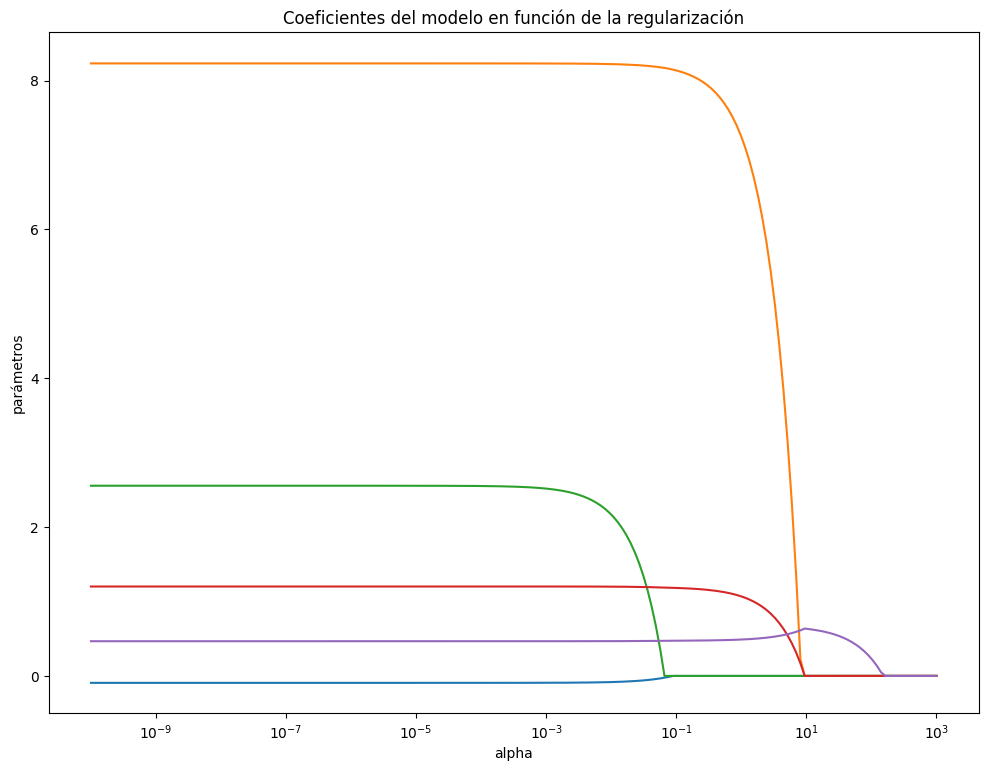

In [33]:
# === EVOLUCIÓN DE LOS PARÁMETROS EN FUNCIÓN DE ALPHA ===
alphas = modelo.alphas_
coefs = []

for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(12, 8.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_ylim([-0.5, None])
ax.set_xlabel('alpha')
ax.set_ylabel('parámetros')
ax.set_title('Coeficientes del modelo en función de la regularización')
plt.show()

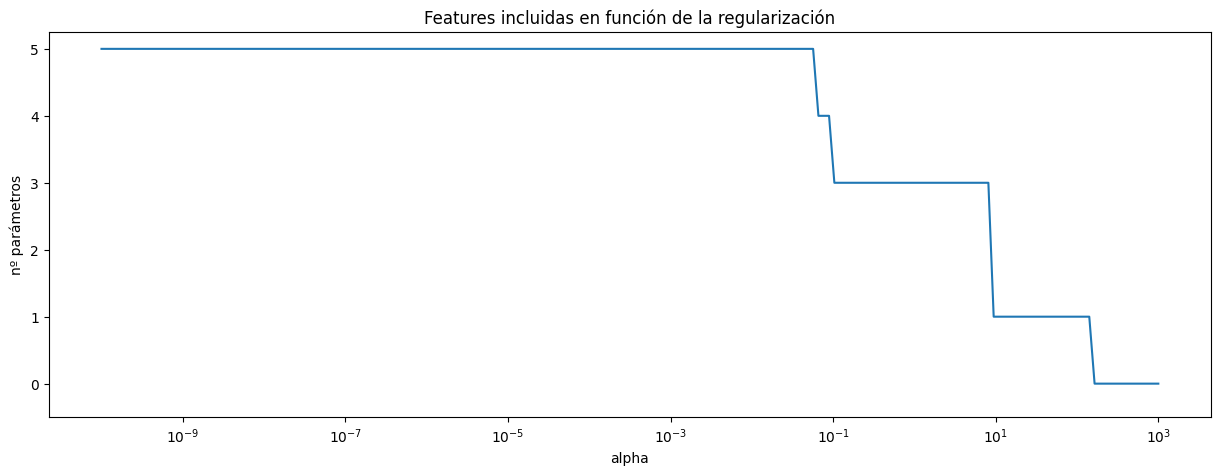

In [34]:
# === Nº DE FEATURES INCLUIDAS EN FUNCIÓN DE ALPHA ===
n_predictores = []

for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train, y_train)
    coef_no_cero = np.sum(modelo_temp.coef_.flatten() != 0)
    n_predictores.append(coef_no_cero)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(alphas, n_predictores)
ax.set_xscale('log')
ax.set_ylim([-0.5, None])
ax.set_xlabel('alpha')
ax.set_ylabel('nº parámetros')
ax.set_title('Features incluidas en función de la regularización')
plt.show()


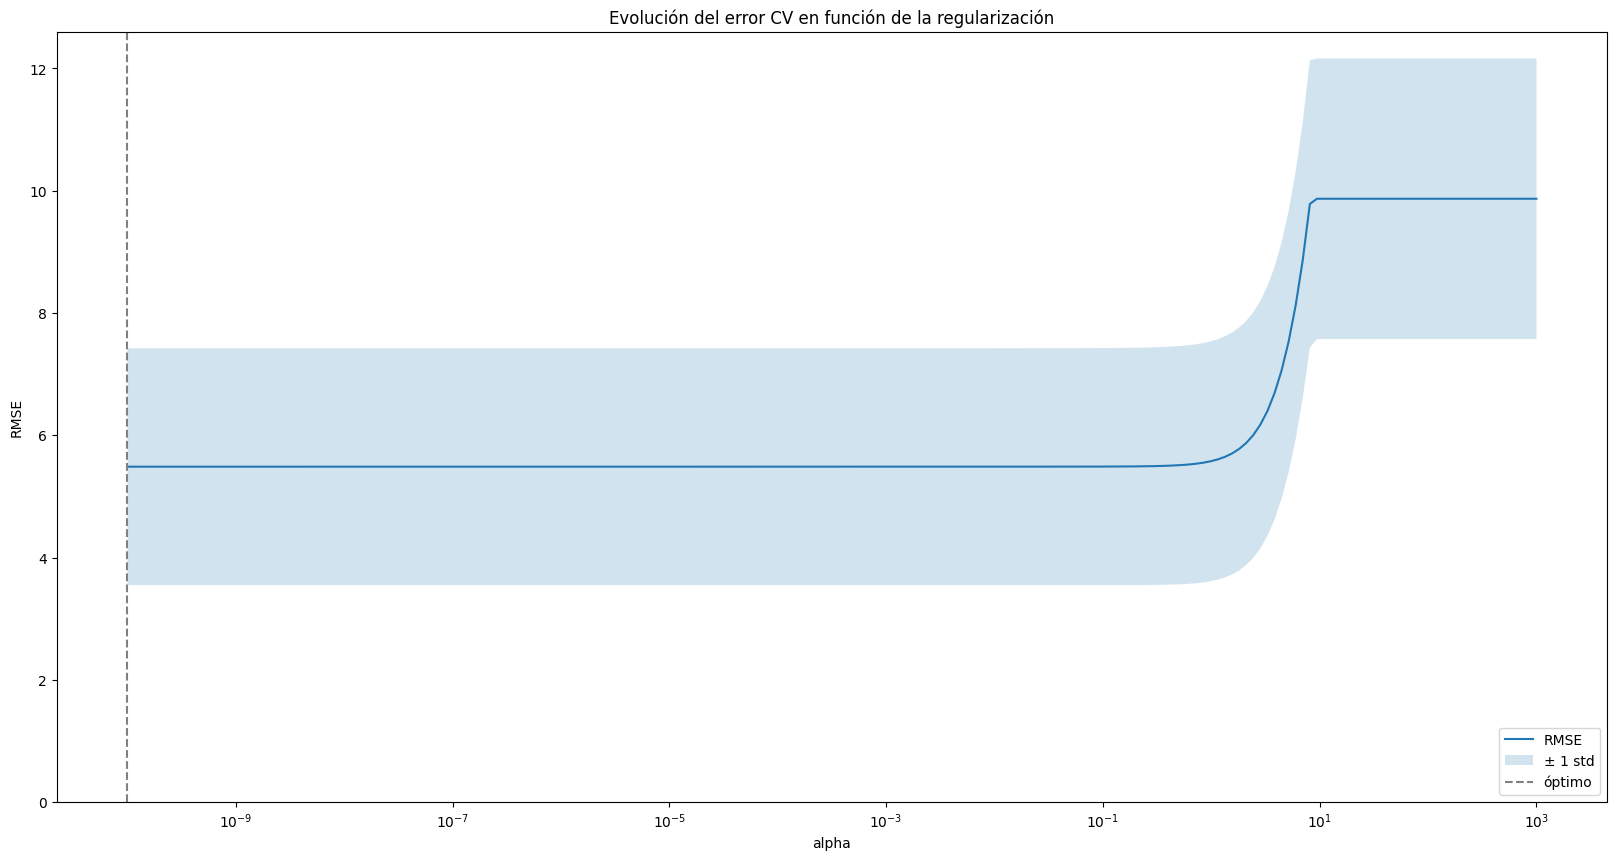

Mejor valor de alpha encontrado: 1e-10


In [35]:
# === EVOLUCIÓN DEL ERROR DE VALIDACIÓN CRUZADA ===
mse_cv = modelo.mse_path_.mean(axis=1)
mse_sd = modelo.mse_path_.std(axis=1)

rmse_cv = np.sqrt(mse_cv)
rmse_sd = np.sqrt(mse_sd)

min_rmse = np.min(rmse_cv)
optimo = modelo.alphas_[np.argmin(rmse_cv)]

fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(modelo.alphas_, rmse_cv, label='RMSE')
ax.fill_between(
    modelo.alphas_,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha=0.2,
    label='± 1 std'
)
ax.axvline(x=optimo, c="gray", linestyle='--', label='óptimo')

ax.set_xscale('log')
ax.set_ylim([0, None])
ax.set_title('Evolución del error CV en función de la regularización')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
plt.legend()
plt.show()

print(f"Mejor valor de alpha encontrado: {modelo.alpha_}")

         predictor      coef
0  passenger_count  0.037693
1        distancia  8.182981
2          feriado -0.524322
3          num_dia -0.036878
4             hora  0.006320


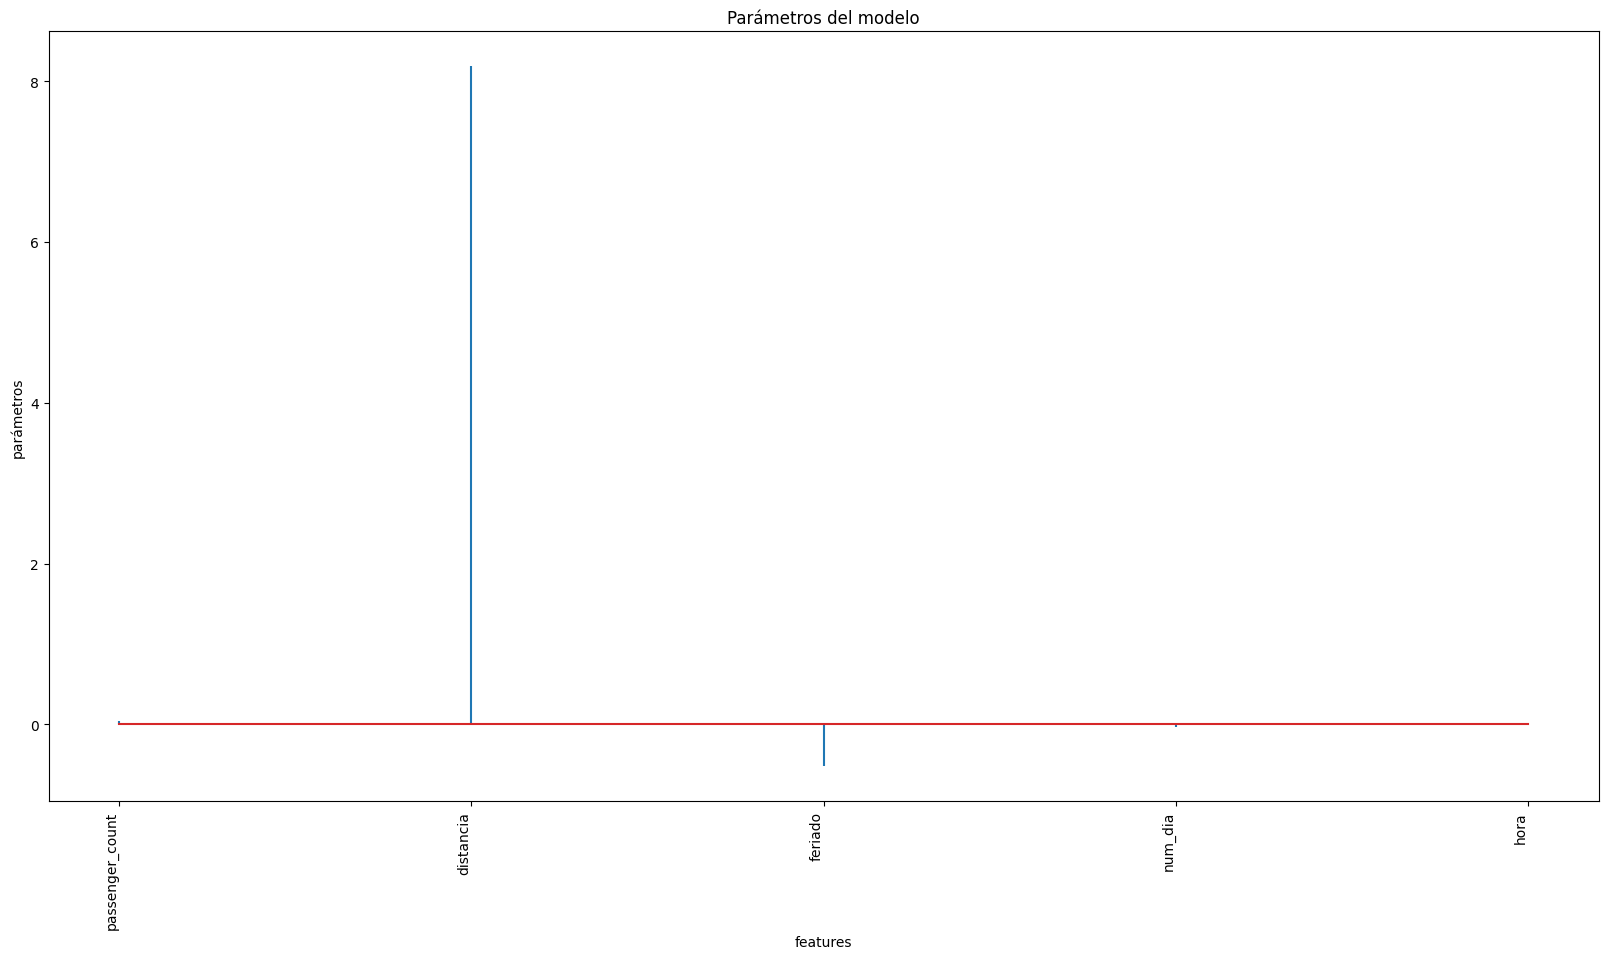

In [36]:
# === COEFICIENTES DEL MODELO ===
df_coeficientes = pd.DataFrame({
    'predictor': X_train.columns,  # asegurate que X_train sea DataFrame
    'coef': modelo.coef_.flatten()
})

# Mostrar sólo los coeficientes distintos de 0
print(df_coeficientes[df_coeficientes.coef != 0])

fig, ax = plt.subplots(figsize=(20, 10))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('features')
ax.set_ylabel('parámetros')
ax.set_title('Parámetros del modelo')
plt.show()

In [37]:
# === PREDICCIONES EN TEST ===
predicciones = modelo.predict(X=X_test).flatten()
predicciones[:10]

array([ 6.97242861, 10.73887539, 11.46383216, 13.05638701, 11.07558685,
       17.22257034,  7.25365109, 21.64755568,  8.10702329, 12.42251913])

In [38]:
# === ERROR EN TEST ===
rmse_lasso = mean_squared_error(
    y_true=y_test,
    y_pred=predicciones,
    
)
print("")
print(f"El error (rmse) de test es: {rmse_lasso}")


El error (rmse) de test es: 27.82878553598512


In [39]:
# === R² EN TEST ===
R2 = metrics.r2_score(y_test, predicciones)
print(f"R² en test: {R2}")

R² en test: 0.6956972584868777


### ElasticNet

In [40]:
# === ENTRENAMIENTO DEL MODELO ===
modelo = ElasticNetCV(
    l1_ratio=[0, 0.1, 0.5, 0.7, 0.9, 0.95, 0.99],
    alphas=np.logspace(-10, 3, 200),
    cv=10
)

_ = modelo.fit(X=X_train, y=y_train.to_numpy().flatten())

C:\Users\marya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\marya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\marya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did no

In [41]:
# === ERROR MEDIO DE CV PARA CADA COMBINACIÓN ===
mean_error_cv = modelo.mse_path_.mean(axis=2)

df_resultados_cv = pd.DataFrame(
    data=mean_error_cv.flatten(),
    index=pd.MultiIndex.from_product(
        iterables=[modelo.l1_ratio, modelo.alphas_],
        names=['l1_ratio', 'modelo.alphas_']
    ),
    columns=["mse_cv"]
)

df_resultados_cv['rmse_cv'] = np.sqrt(df_resultados_cv['mse_cv'])
df_resultados_cv = df_resultados_cv.reset_index().sort_values('mse_cv', ascending=True)
print(df_resultados_cv.head())

     l1_ratio  modelo.alphas_     mse_cv   rmse_cv
108       0.0        0.000088  30.093061  5.485714
109       0.0        0.000076  30.093061  5.485714
107       0.0        0.000102  30.093061  5.485714
110       0.0        0.000065  30.093061  5.485714
308       0.1        0.000088  30.093061  5.485714


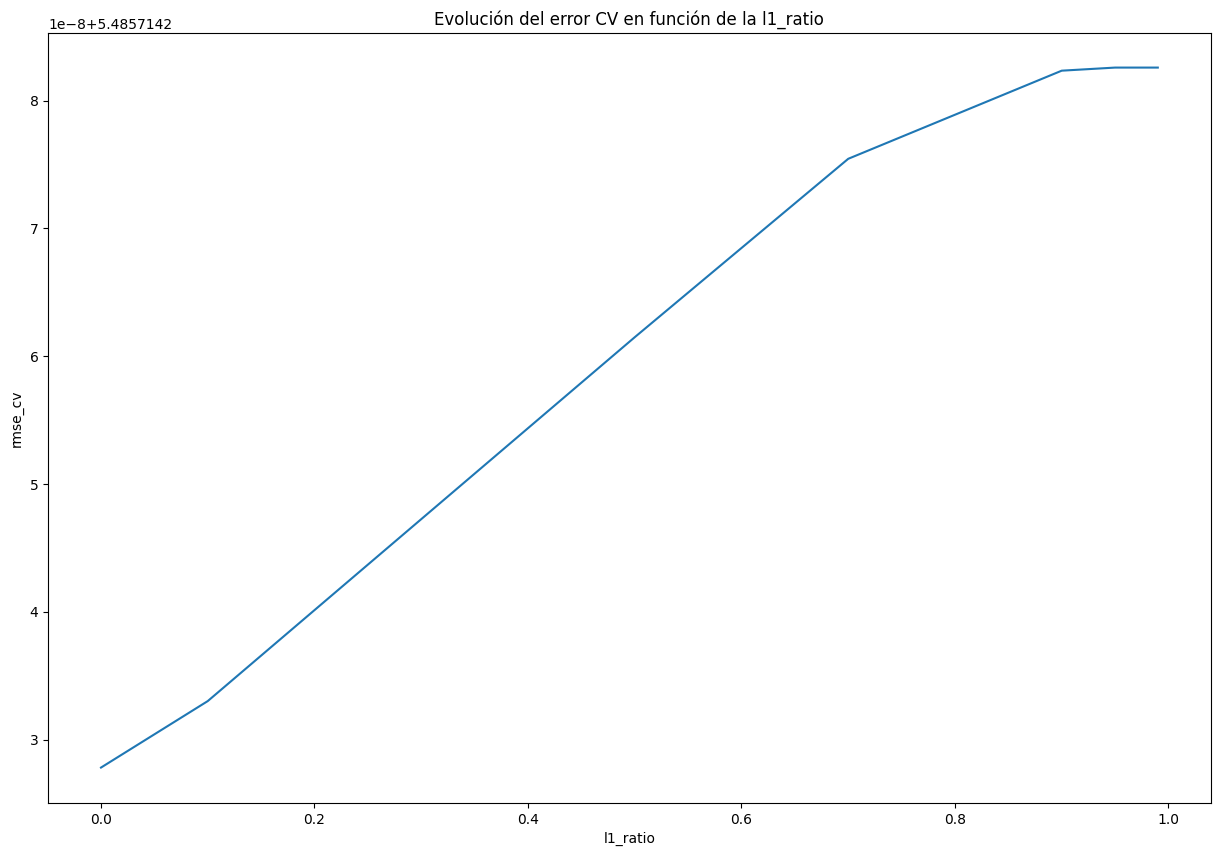

In [42]:
# === GRÁFICO: RMSE vs l1_ratio ===
fig, ax = plt.subplots(figsize=(15, 10))
df_resultados_cv.groupby('l1_ratio')['rmse_cv'].min().plot(ax=ax)
ax.set_title('Evolución del error CV en función de la l1_ratio')
ax.set_xlabel('l1_ratio')
ax.set_ylabel('rmse_cv')
plt.show()

In [43]:
# === MEJOR ALPHA Y l1_ratio ===
print(f"Mejor valor de alpha encontrado: {modelo.alpha_}")
print(f"Mejor valor de l1_ratio encontrado: {modelo.l1_ratio_}")

Mejor valor de alpha encontrado: 8.804883581643464e-05
Mejor valor de l1_ratio encontrado: 0.0


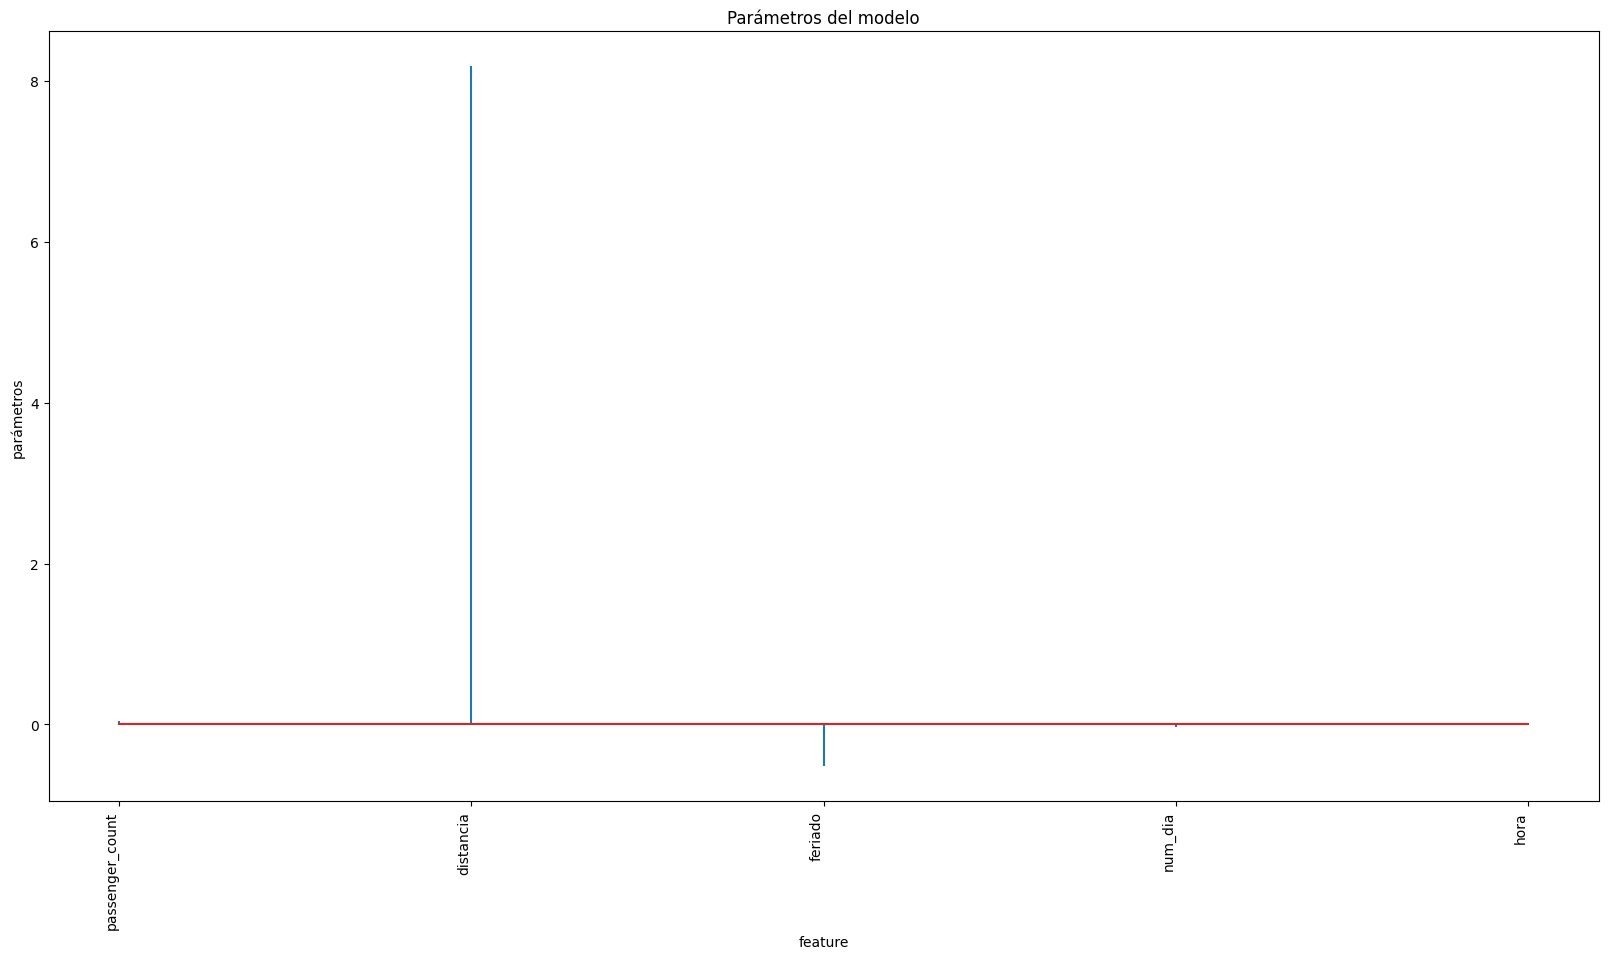

In [44]:
# === COEFICIENTES DEL MODELO ===
df_coeficientes = pd.DataFrame({
    'predictor': X_train.columns,
    'coef': modelo.coef_.flatten()
})

fig, ax = plt.subplots(figsize=(20, 10))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('feature')
ax.set_ylabel('parámetros')
ax.set_title('Parámetros del modelo')
plt.show()

In [45]:
# === PREDICCIONES ===
predicciones = modelo.predict(X=X_test).flatten()
print(predicciones[:10])

[ 6.97273397 10.73888772 11.46382284 13.05620886 11.07560603 17.22199977
  7.25400173 21.64656642  8.10724808 12.42237866]


In [46]:
# === MÉTRICAS ===
rmse_elastic = mean_squared_error(
    y_true=y_test,
    y_pred=predicciones,
    
)

print("")
print(f"El error (rmse) de test es: {rmse_elastic}")

R2 = metrics.r2_score(y_test, predicciones)
print(f"R² en test: {R2}")


El error (rmse) de test es: 27.828637114261667
R² en test: 0.6956988814516056


### Comparación de modelos por RMSE

In [ ]:
y_pred_ols = modelo.predict(X_test)
rmse_ols = mean_squared_error(y_test, y_pred_ols)

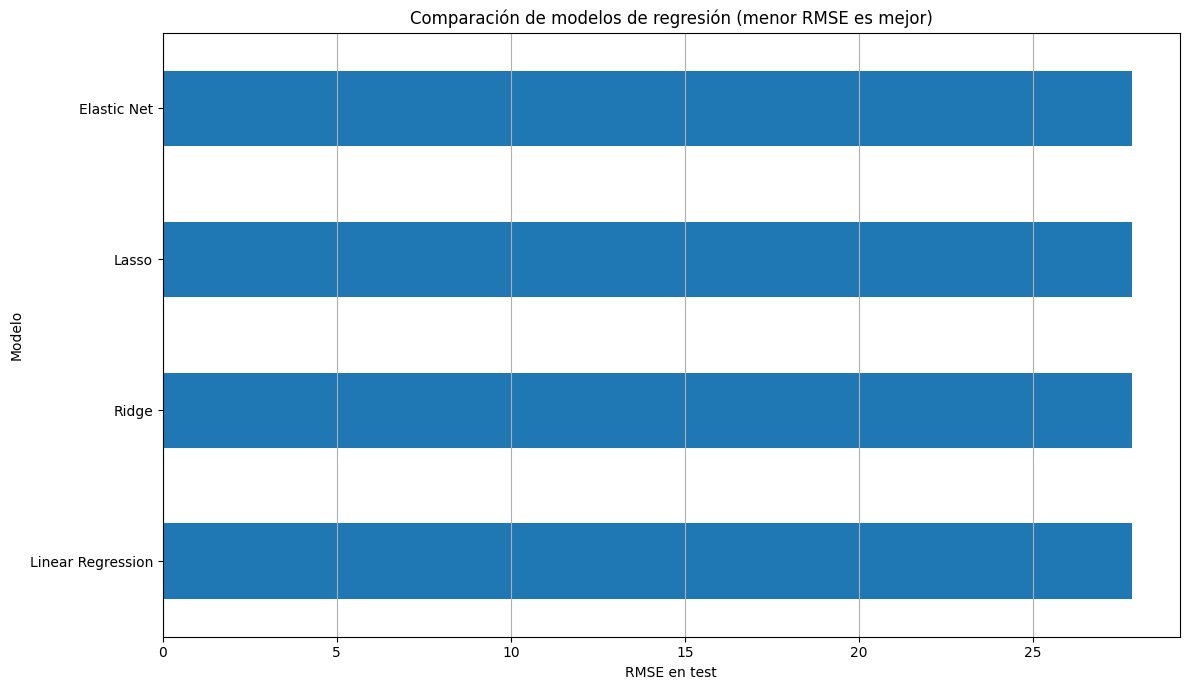

,modelo,test_rmse
1,Ridge,27.828635
0,Linear Regression,27.828637
3,Elastic Net,27.828637
2,Lasso,27.828786


In [ ]:
# === COMPARACIÓN FINAL DE MODELOS ===
df_comparacion = pd.DataFrame({
    'modelo': ['Linear Regression', 'Ridge', 'Lasso', 'Elastic Net'],
    'test_rmse': [rmse_ols, rmse_ridge, rmse_lasso, rmse_elastic]
})

fig, ax = plt.subplots(figsize=(12, 7))
df_comparacion.set_index('modelo').plot(kind='barh', ax=ax, legend=False)
ax.set_xlabel('RMSE en test')
ax.set_ylabel('Modelo')
ax.set_title('Comparación de modelos de regresión')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

df_comparacion.sort_values(by='test_rmse')